In [ ]:
!pip install -q diffusers transformers accelerate scipy ftfy torch torchvision scikit-image torch-fidelity requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.6 MB/s eta 0:00:00


In [ ]:
import torch
from diffusers import StableDiffusionPipeline
import torchvision.transforms as T
from PIL import Image
import os
import random
import numpy as np
from skimage.metrics import structural_similarity as ssim
import pandas as pd


In [ ]:
# Dispositivo
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Usando dispositivo: {device}")

pipe = StableDiffusionPipeline.from_pretrained(
    "CompVis/stable-diffusion-v1-4",
    torch_dtype=torch.float16,
    safety_checker=None,
    requires_safety_checker=False
)
pipe = pipe.to(device)
pipe.enable_attention_slicing()

Usando dispositivo: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

scheduler_config.json:   0%|          | 0.00/313 [00:00<?, ?B/s]

...

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


In [ ]:
output_dir = "/content/generated_cat_images"
os.makedirs(output_dir, exist_ok=True)

prompts = [
    "a high-resolution photo of an Abyssinian cat with short reddish-brown coat, elegant slender body, amendo-shaped eyes, natural lighting, neutral background, studio-like quality",
    "a high-resolution photo of a Bengal cat with spotted or marbled coat, muscular wild-looking body, large expressive eyes, natural indoor lighting, plain background, dynamic pose",
    "a high-resolution photo of a Siamese cat with short cream coat, dark extremities, striking blue eyes, slender body, soft natural lighting, simple neutral background, close-up pose"
]

num_images_per_prompt = 50
guidance_scale = 8
num_inference_steps = 50

print("Gerando imagens de gatos...")
generated_images_paths = {}
for i, prompt in enumerate(prompts):
    print(f"Prompt {i+1}/{len(prompts)}: {prompt}")
    prompt_paths = []
    for j in range(num_images_per_prompt):
        image = pipe(prompt, num_inference_steps=num_inference_steps, guidance_scale=guidance_scale).images[0]
        filename = f"cat_prompt_{i}_image_{j}.png"
        filepath = os.path.join(output_dir, filename)
        image.save(filepath)
        prompt_paths.append(filepath)
        print(f"  ✓ Imagem {j+1}/{num_images_per_prompt} salva: {filename}")
    generated_images_paths[prompt] = prompt_paths

print(f"\n✅ Imagens geradas salvas em {output_dir}/")

Gerando imagens de gatos...
Prompt 1/3: a high-resolution photo of an Abyssinian cat with short reddish-brown coat, elegant slender body, amendo-shaped eyes, natural lighting, neutral background, studio-like quality


  0%|          | 0/50 [00:00<?, ?it/s]

  ✓ Imagem 1/50 salva: cat_prompt_0_image_0.png


  0%|          | 0/50 [00:00<?, ?it/s]

  ✓ Imagem 2/50 salva: cat_prompt_0_image_1.png


...

  ✓ Imagem 48/50 salva: cat_prompt_2_image_47.png


  0%|          | 0/50 [00:00<?, ?it/s]

  ✓ Imagem 49/50 salva: cat_prompt_2_image_48.png


  0%|          | 0/50 [00:00<?, ?it/s]

  ✓ Imagem 50/50 salva: cat_prompt_2_image_49.png

✅ Imagens geradas salvas em /content/generated_cat_images/


In [ ]:
# Download do Oxford-IIIT Pet Dataset
!wget -q https://thor.robots.ox.ac.uk/~vgg/data/pets/images.tar.gz -O /content/images.tar.gz
print("Download concluído.")

✅ Download concluído.


In [ ]:
# Extração do dataset para uma pasta temporária
os.makedirs('/content/temp_pet_images', exist_ok=True)
!tar -xzf /content/images.tar.gz -C /content/temp_pet_images
!rm /content/images.tar.gz
print("Dataset extraído em /content/temp_pet_images/")

Dataset extraído em /content/temp_pet_images/


In [ ]:
# Filtrar e preparar imagens reais de gatos (somente Abyssinian, Bengal, Siamese)
real_base_dir = "/content/temp_pet_images/images"  # Corrigido para o diretório extraído
real_dir = "/content/real_cat_images"
os.makedirs(real_dir, exist_ok=True)

# Raças específicas a filtrar
target_breeds = ['Abyssinian', 'Bengal', 'Siamese']

def filter_images(base_dir, target_breeds, num_per_breed=50):  # Ajustado para 50
    paths = []
    print("Filtrando imagens reais de gatos...")
    all_files = [f for f in os.listdir(base_dir) if f.lower().endswith('.jpg')]

    breed_files = {breed: [] for breed in target_breeds}
    for file in all_files:
        for breed in target_breeds:
            if file.startswith(breed + '_'):
                full_path = os.path.join(base_dir, file)
                breed_files[breed].append(full_path)
                break

    for breed in target_breeds:
        if breed_files[breed]:
            available = len(breed_files[breed])
            selected = random.sample(breed_files[breed], min(num_per_breed, available))
            paths.extend(selected)
            print(f" Raça '{breed}': {len(selected)} imagens (disponíveis: {available})")
        else:
            print(f" Raça '{breed}' não encontrada")

    return paths

# Coleta
cat_paths = filter_images(real_base_dir, target_breeds, 50)
print(f"\nColetadas: {len(cat_paths)} imagens de gatos (total esperado: {len(target_breeds) * 50})")

if len(cat_paths) == 0:
    print(" Nenhuma imagem encontrada.")
else:
    transform_real = T.Compose([T.Resize((512, 512)), T.ToTensor()])
    saved_images = set()  # Para evitar sobreposição
    base_idx = {0: 0, 1: 50, 2: 100}  # Índices base por raça
    for idx, path in enumerate(cat_paths):
        try:
            if os.path.exists(path):
                img_pil = Image.open(path).convert('RGB')
                img_tensor = transform_real(img_pil)
                img_save = T.ToPILImage()(img_tensor)
                breed_idx = target_breeds.index(os.path.basename(path).split('_')[0])
                unique_idx = base_idx[breed_idx] + (idx % 50)  # Índice único por raça
                base_idx[breed_idx] += 1  # Incrementa para a próxima imagem
                filename = f"real_cat_prompt_{breed_idx}_img_{unique_idx}.png"
                filepath = os.path.join(real_dir, filename)
                if filename not in saved_images:
                    img_save.save(filepath)
                    saved_images.add(filename)
                    print(f"  ✓ Imagem real {idx+1}/{len(cat_paths)} salva: {filename}")
            else:
                print(f"  ✗ Caminho inválido: {path}")
        except Exception as e:
            print(f"  ✗ Erro em {os.path.basename(path)}: {e}")

    print(f"\n✅ Imagens reais processadas salvas em {real_dir}/ (fonte: {real_base_dir})")

Filtrando imagens reais de gatos...
  ✓ Raça 'Abyssinian': 50 imagens (disponíveis: 200)
  ✓ Raça 'Bengal': 50 imagens (disponíveis: 200)
  ✓ Raça 'Siamese': 50 imagens (disponíveis: 200)

Coletadas: 150 imagens de gatos (total esperado: 150)
  ✓ Imagem real 1/150 salva: real_cat_prompt_0_img_0.png
  ✓ Imagem real 2/150 salva: real_cat_prompt_0_img_2.png
  ✓ Imagem real 3/150 salva: real_cat_prompt_0_img_4.png
  ✓ Imagem real 4/150 salva: real_cat_prompt_0_img_6.png
  ✓ Imagem real 5/150 salva: real_cat_prompt_0_img_8.png
  ✓ Imagem real 6/150 salva: real_cat_prompt_0_img_10.png
  ✓ Imagem real 7/150 salva: real_cat_prompt_0_img_12.png
  ✓ Imagem real 8/150 salva: real_cat_prompt_0_img_14.png
  ✓ Imagem real 9/150 salva: real_cat_prompt_0_img_16.png
  ✓ Imagem real 10/150 salva: real_cat_prompt_0_img_18.png
  ✓ Imagem real 11/150 salva: real_cat_prompt_0_img_20.png
  ✓ Imagem real 12/150 salva: real_cat_prompt_0_img_22.png
  ✓ Imagem real 13/150 salva: real_cat_prompt_0_img_24.png
  ✓ 

In [ ]:
# Funções de Avaliação
import numpy as np
from PIL import Image
import os
from skimage.metrics import structural_similarity as ssim

def calculate_ssim_by_breed(generated_dir, breed_index):
    images = []
    for img_name in os.listdir(generated_dir):
        if img_name.startswith(f"cat_prompt_{breed_index}_"):
            img_path = os.path.join(generated_dir, img_name)
            try:
                with Image.open(img_path) as img:
                    img = np.array(img.convert('RGB'))
                    images.append(img)
            except Exception as e:
                print(f" Erro ao carregar {img_name}: {e}")
                continue
    if not images:
        print(f" Nenhuma imagem válida encontrada para breed_index {breed_index}")
        return np.nan
    ssim_scores = []
    for i in range(len(images)):
        for j in range(i + 1, len(images)):
            try:
                ssim_val = ssim(images[i], images[j], channel_axis=2, data_range=255.0)
                ssim_scores.append(ssim_val)
            except Exception as e:
                print(f" Erro ao calcular SSIM entre imagens {i} e {j}: {e}")
                continue
    return np.mean(ssim_scores) if ssim_scores else np.nan

def calculate_fid_is_ppl(real_dir, generated_dir):
    from torch_fidelity import calculate_metrics
    metrics = calculate_metrics(
        input1=real_dir,
        input2=generated_dir,
        cuda=torch.cuda.is_available(),
        isc=True,
        fid=True,
        verbose=True
    )
    return metrics

In [ ]:

# Avaliação Completa

results = {}
for i in range(len(prompts)):
    ssim_score = calculate_ssim_by_breed(output_dir, i)
    results[f"breed_{i}_ssim_diversity"] = ssim_score

print("\nCalculando FID e IS...")
metrics = calculate_metrics(
    input1=real_dir,
    input2=output_dir,
    cuda=torch.cuda.is_available(),
    isc=True,  # Inception Score
    fid=True,  # Fréchet Inception Distance
    verbose=True
)
results.update(metrics)

# Salvar resultados
df_results = pd.DataFrame(list(results.items()), columns=['Métrica', 'Valor'])
df_results.to_csv('/content/results_cats.csv', index=False)
print("\n Resultados:")
print(df_results)


Calculando FID e IS...


Creating feature extractor "inception-v3-compat" with features ['logits_unbiased', '2048']
Extracting features from input1
Looking for samples non-recursivelty in "/content/real_cat_images" with extensions png,jpg,jpeg
Found 150 samples
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Processing samples
Extracting features from input2
Looking for samples non-recursivelty in "/content/generated_cat_images" with extensions png,jpg,jpeg
Found 150 samples
Processing samples
Inception Score: 2.7448123192905602 ± 0.5249532429356075



 Resultados:
                      Métrica       Valor
0      breed_0_ssim_diversity    0.359169
1      breed_1_ssim_diversity    0.264088
2      breed_2_ssim_diversity    0.390471
3        inception_score_mean    2.744812
4         inception_score_std    0.524953
5  frechet_inception_distance  105.438484


Frechet Inception Distance: 105.43848374021903


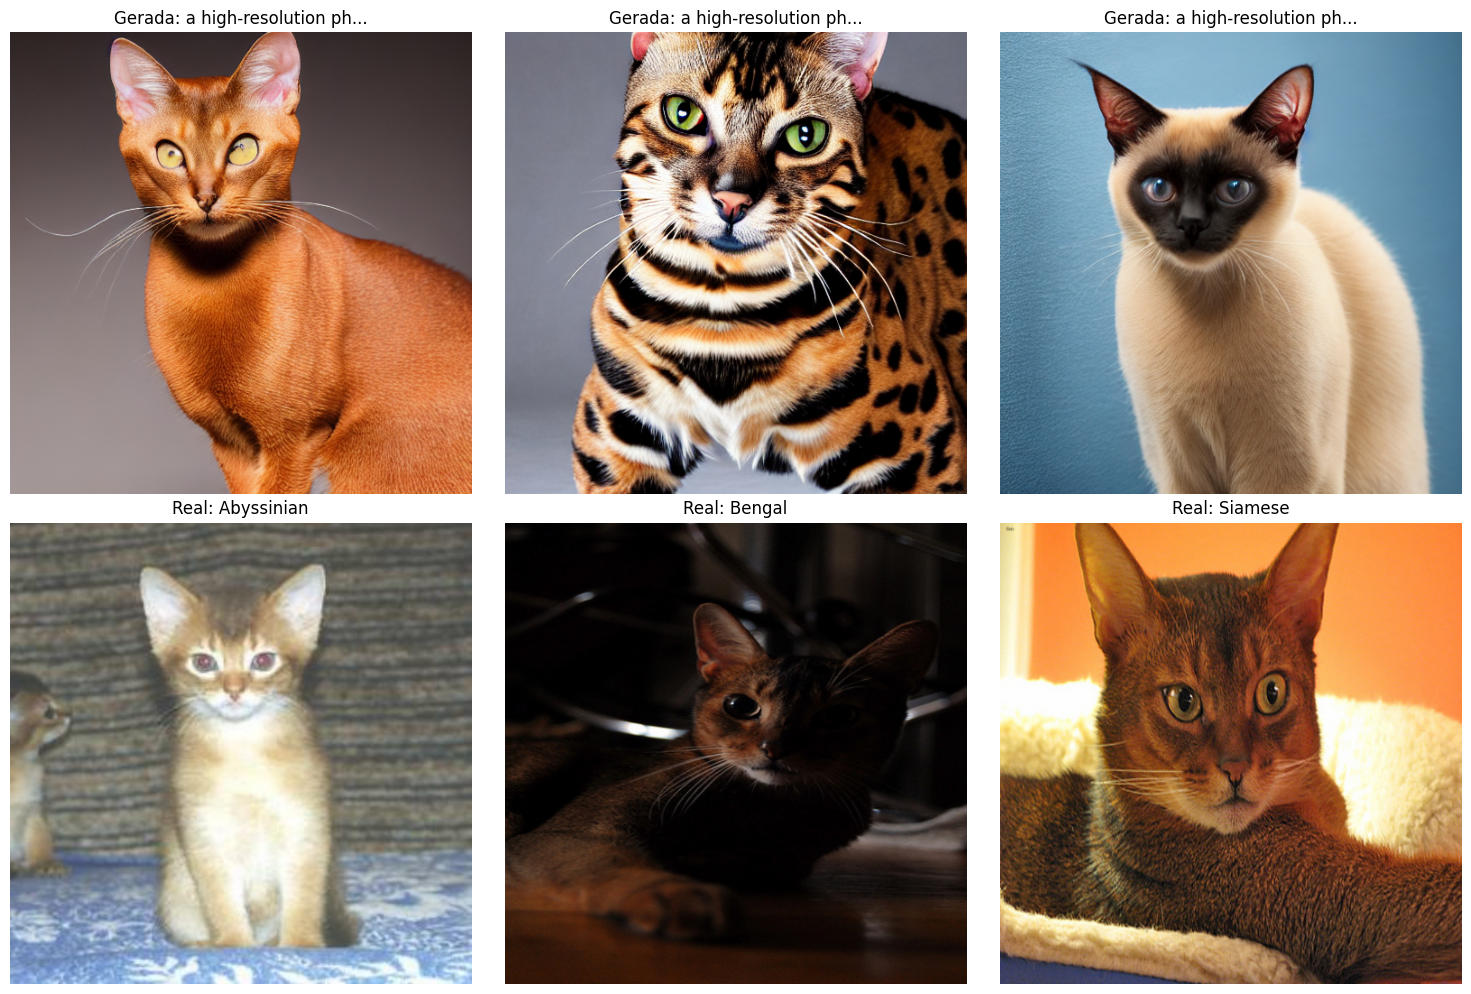

In [ ]:
# Visualização
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

# Imagens geradas
for i in range(3):
    img_path = generated_images_paths[prompts[i]][0]
    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].set_title(f"Gerada: {prompts[i][:20]}...")
    axes[i].axis('off')

# Imagens reais
real_img_paths = [os.path.join(real_dir, f) for f in os.listdir(real_dir) if f.startswith('real_cat_prompt_0_')]
for i in range(3, 6):
    img = Image.open(real_img_paths[i-3])
    axes[i].set_title(f"Real: {target_breeds[i-3]}")
    axes[i].imshow(img)
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('/content/sample_cat_images.png')
plt.show()

In [ ]:
# Comando para excluir uma pasta e seu conteúdo
!rm -r /content/real_cat_images/
print("Pasta e conteúdo removidos com sucesso!")

Pasta e conteúdo removidos com sucesso!


In [ ]:
!zip -r real_cat_images.zip /content/real_cat_images
from google.colab import files
files.download("real_cat_images.zip")
